In [14]:
from constants import users_list, data_path
from lib import spoti, genre_normalizer, plotting, preprocessing, dimensionality_reduction

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import json
import os
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.metrics import mean_squared_error
import random
import time
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors as SklearnNearestNeighbors, NeighborhoodComponentsAnalysis
from sklearn.metrics import pairwise_distances
import pickle
import numpy as np
from typing import List, Dict, Tuple, Optional, Any, Callable
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from IPython.display import display, HTML
from recommenders.nearest_neighbours import NearestNeighboursRecommender

# Import data

In [15]:
df = spoti.load_all_tracks(base_path=data_path.DATA_PATH, users=users_list.USERS, load_spotify_tracks=True)
df

,album,artists,available_markets,disc_number,duration_ms,episode,explicit,external_ids,external_urls,href,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,affinity,release_year,normalized_genres
0,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,251488,False,False,{'isrc': 'GBF088590110'},{'spotify': 'https://open.spotify.com/track/4R...,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,...,audio_features,spotify:track:4RvWPyQ5RL0ao9LPZeSouE,https://api.spotify.com/v1/tracks/4RvWPyQ5RL0a...,https://api.spotify.com/v1/audio-analysis/4RvW...,251489,4,NaN,NaN,NaN,NaN
1,"{'album_type': 'compilation', 'artists': [{'ex...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,256146,False,False,{'isrc': 'GBF088590112'},{'spotify': 'https://open.spotify.com/track/74...,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,...,audio_features,spotify:track:748yv6bb3l3CcKS45a6SZ8,https://api.spotify.com/v1/tracks/748yv6bb3l3C...,https://api.spotify.com/v1/audio-analysis/748y...,256147,4,NaN,NaN,NaN,NaN
2,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,209106,False,False,{'isrc': 'GBUM71103440'},{'spotify': 'https://open.spotify.com/track/7n...,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,...,audio_features,spotify:track:7nhWtCc3v6Vem80gYPlppQ,https://api.spotify.com/v1/tracks/7nhWtCc3v6Ve...,https://api.spotify.com/v1/audio-analysis/7nhW...,209107,4,NaN,NaN,NaN,NaN
3,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,170786,False,False,{'isrc': 'GBUM71029609'},{'spotify': 'https://open.spotify.com/track/4v...,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,...,audio_features,spotify:track:4vhVDkSx9RSb2k6mWFMYNI,https://api.spotify.com/v1/tracks/4vhVDkSx9RSb...,https://api.spotify.com/v1/audio-analysis/4vhV...,170787,4,NaN,NaN,NaN,NaN
4,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CL, CO, CR, CY, C...",1,264253,False,False,{'isrc': 'GBUM71029621'},{'spotify': 'https://open.spotify.com/track/5R...,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,...,audio_features,spotify:track:5RYLa5P4qweEAKq5U1gdcK,https://api.spotify.com/v1/tracks/5RYLa5P4qweE...,https://api.spotify.com/v1/audio-analysis/5RYL...,264253,4,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20317,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AL, AM, AT, AZ, BA, BE, BG, BY, CH, CW, C...",1,251880,False,False,{'isrc': 'GBN9Y1100001'},{'spotify': 'https://open.spotify.com/track/3z...,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,...,audio_features,spotify:track:3z7dWKRsjDNM24ohLKZBnA,https://api.spotify.com/v1/tracks/3z7dWKRsjDNM...,https://api.spotify.com/v1/audio-analysis/3z7d...,251880,4,NaN,NaN,1967.0,"[rock, rock, rock, rock, rock, rock, rock]"
20318,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,193853,False,False,{'isrc': 'GBLTP1700005'},{'spotify': 'https://open.spotify.com/track/1V...,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,...,audio_features,spotify:track:1VofMhhL98pewltVGBSmCW,https://api.spotify.com/v1/tracks/1VofMhhL98pe...,https://api.spotify.com/v1/audio-analysis/1Vof...,193853,3,NaN,NaN,2017.0,"[rock, rock, rock, rock, rock]"
20319,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,295493,False,False,{'isrc': 'GBLTP170

# Distribution

KeyboardInterrupt: 

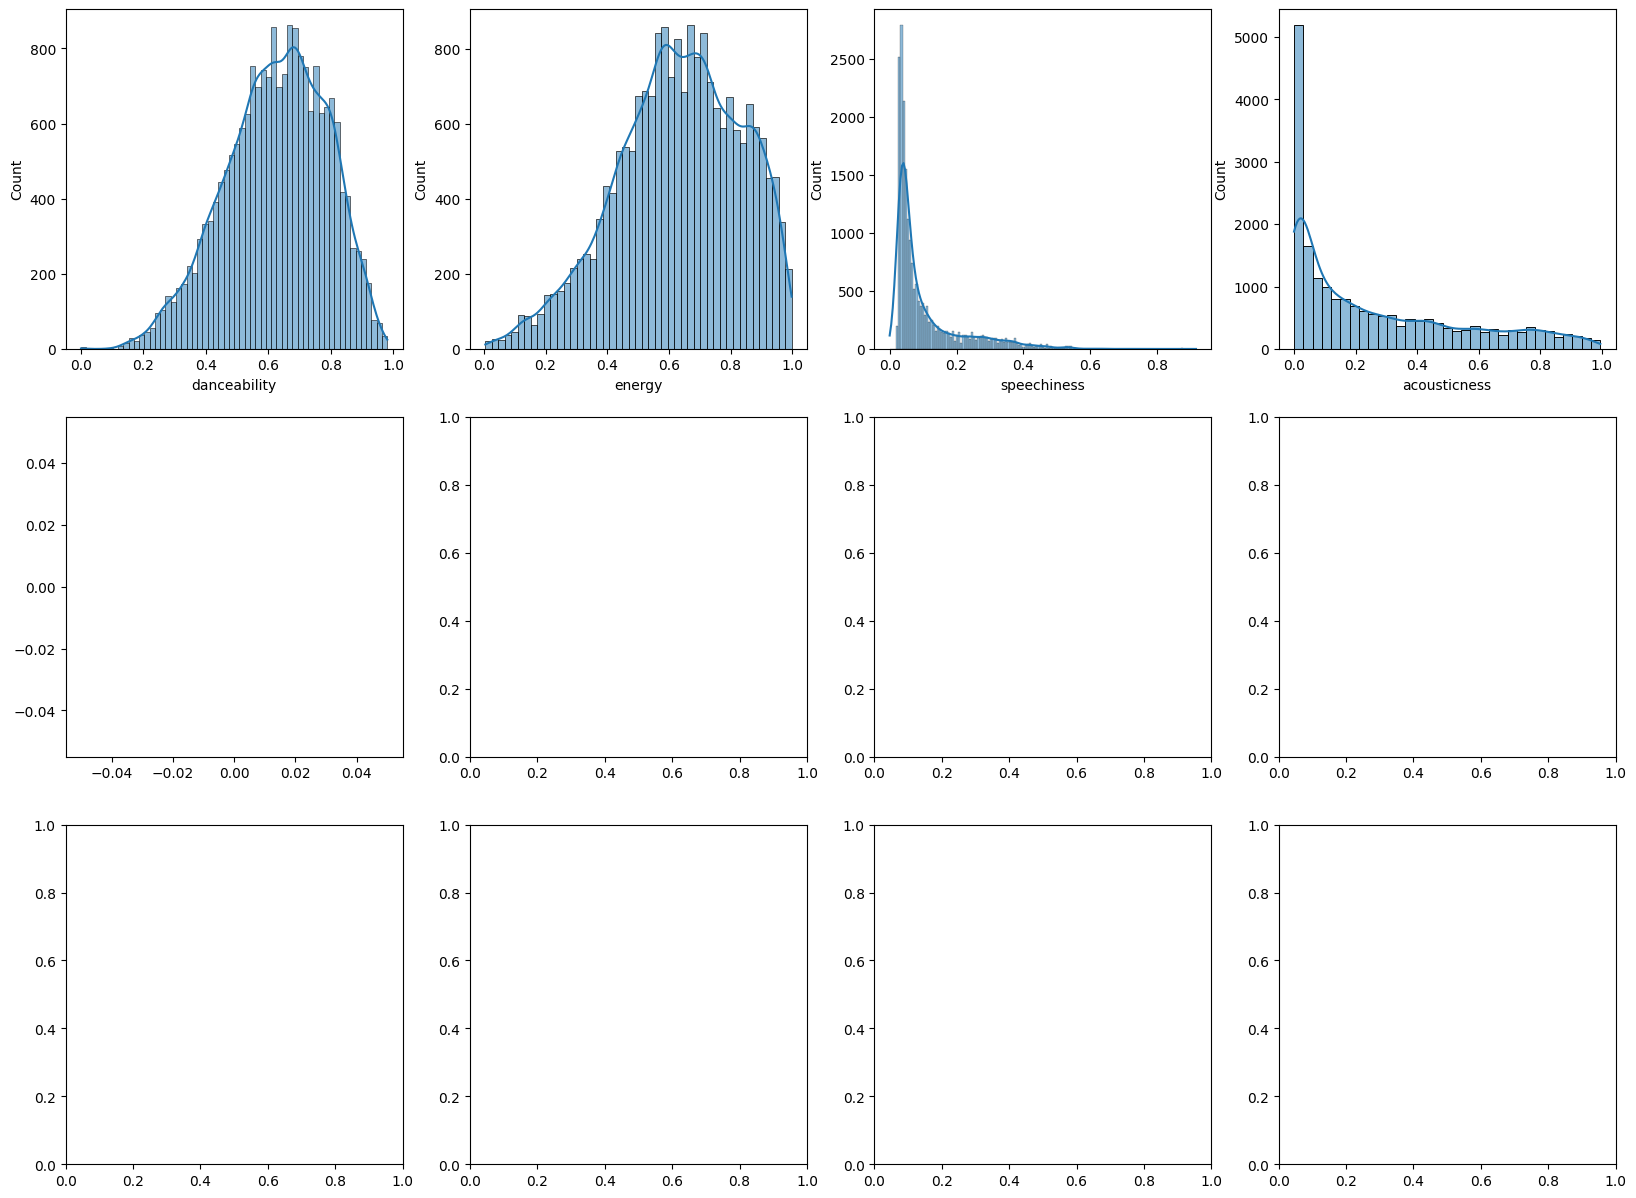

In [16]:
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=4, rows=3)

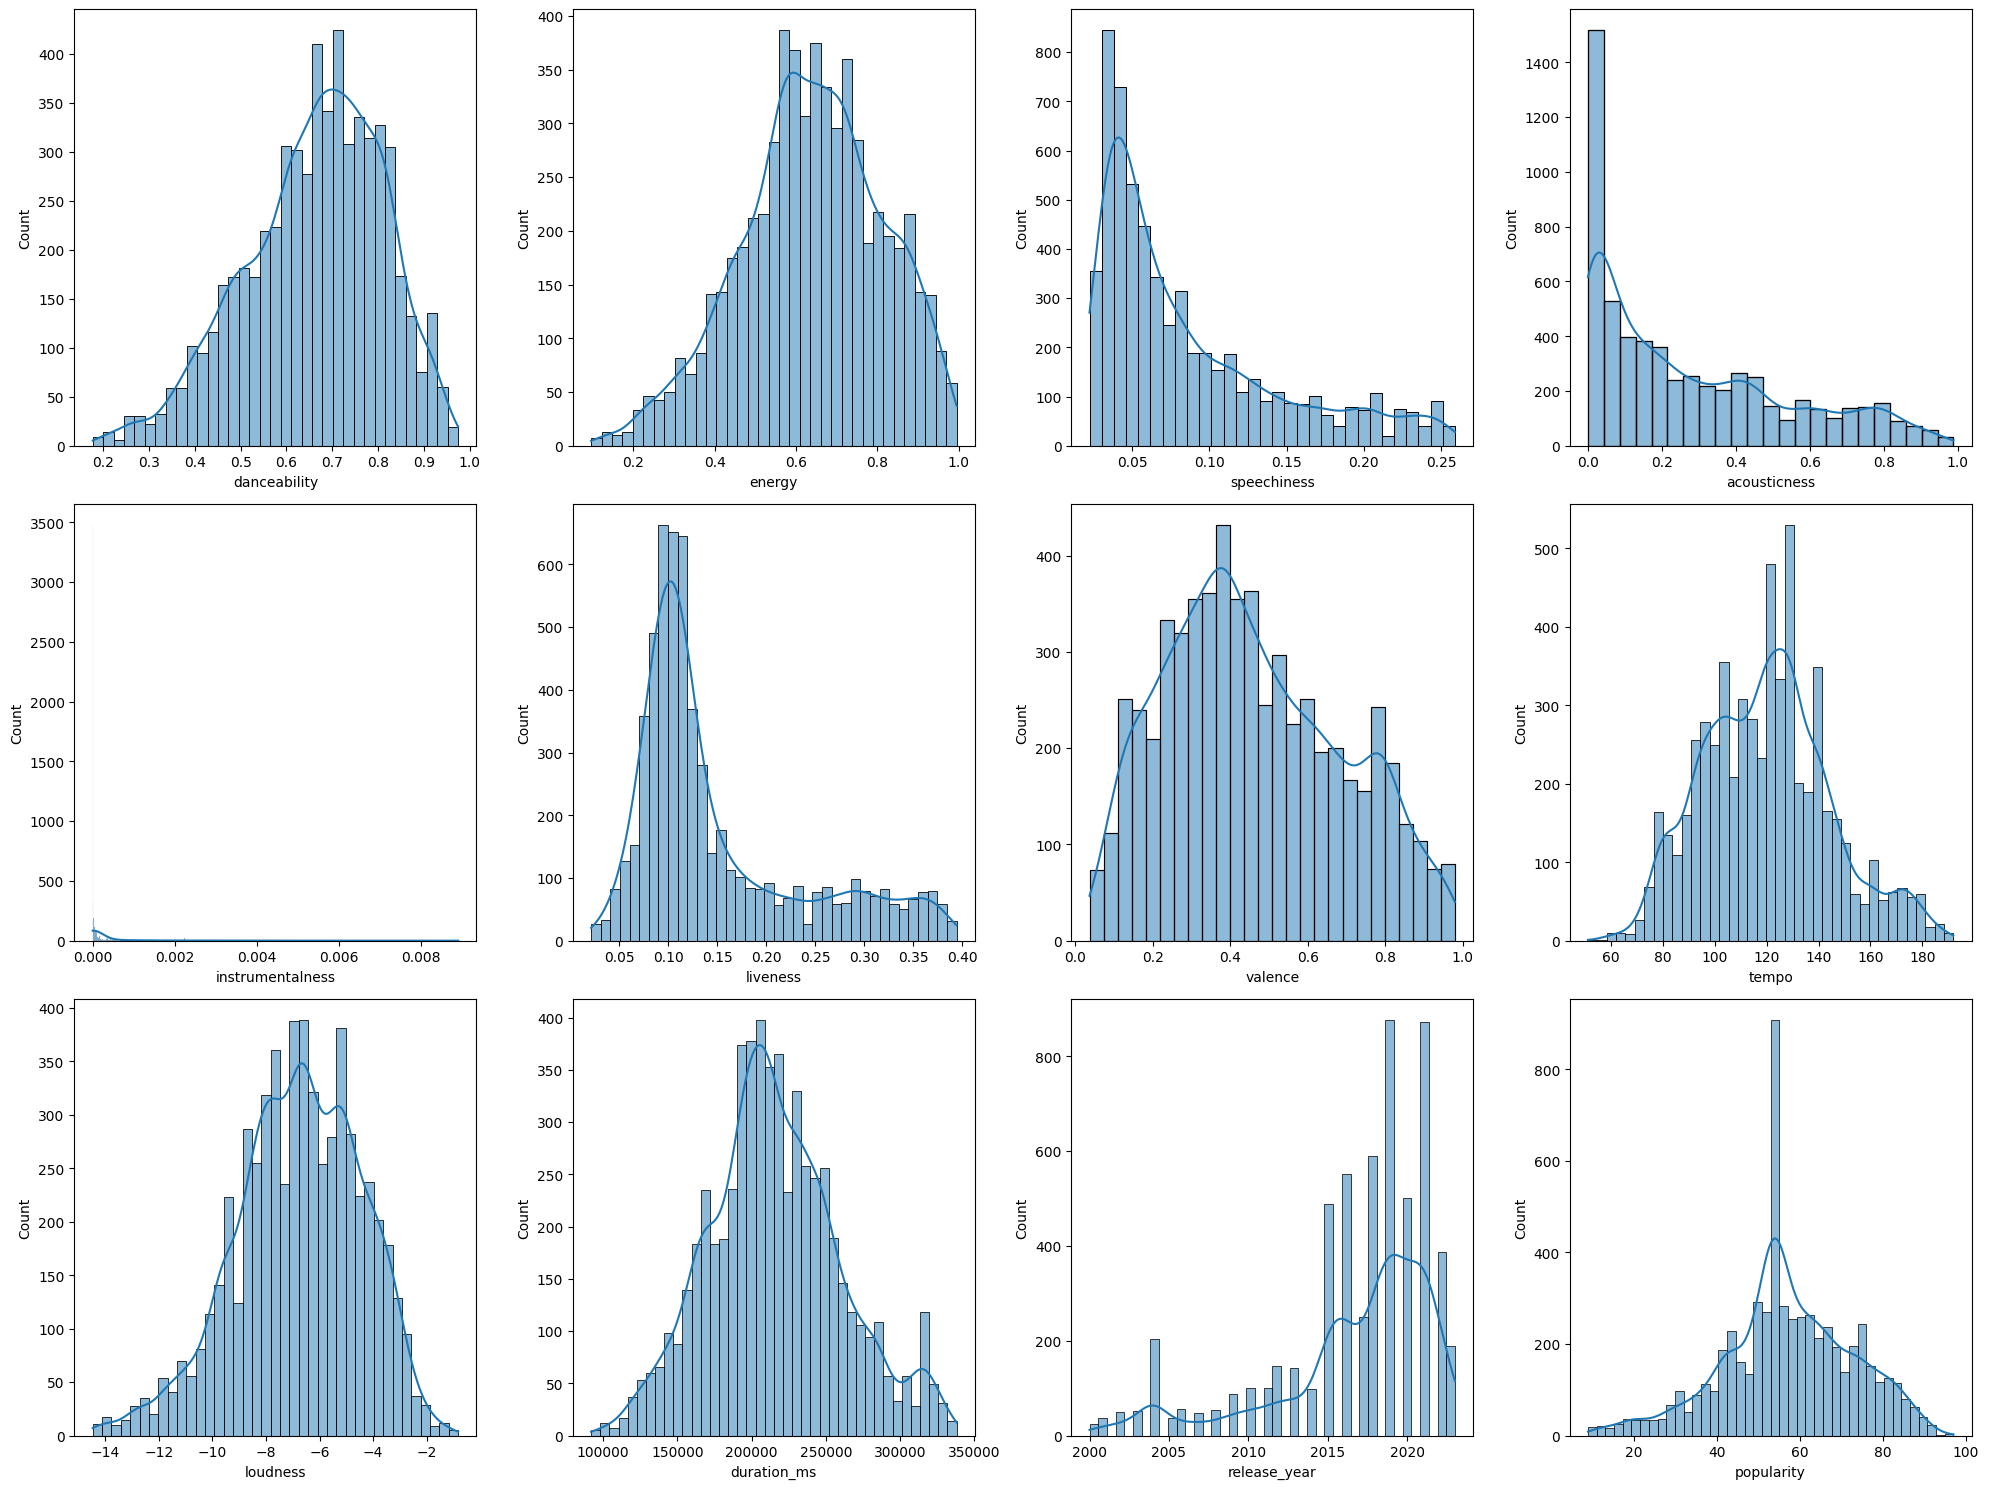

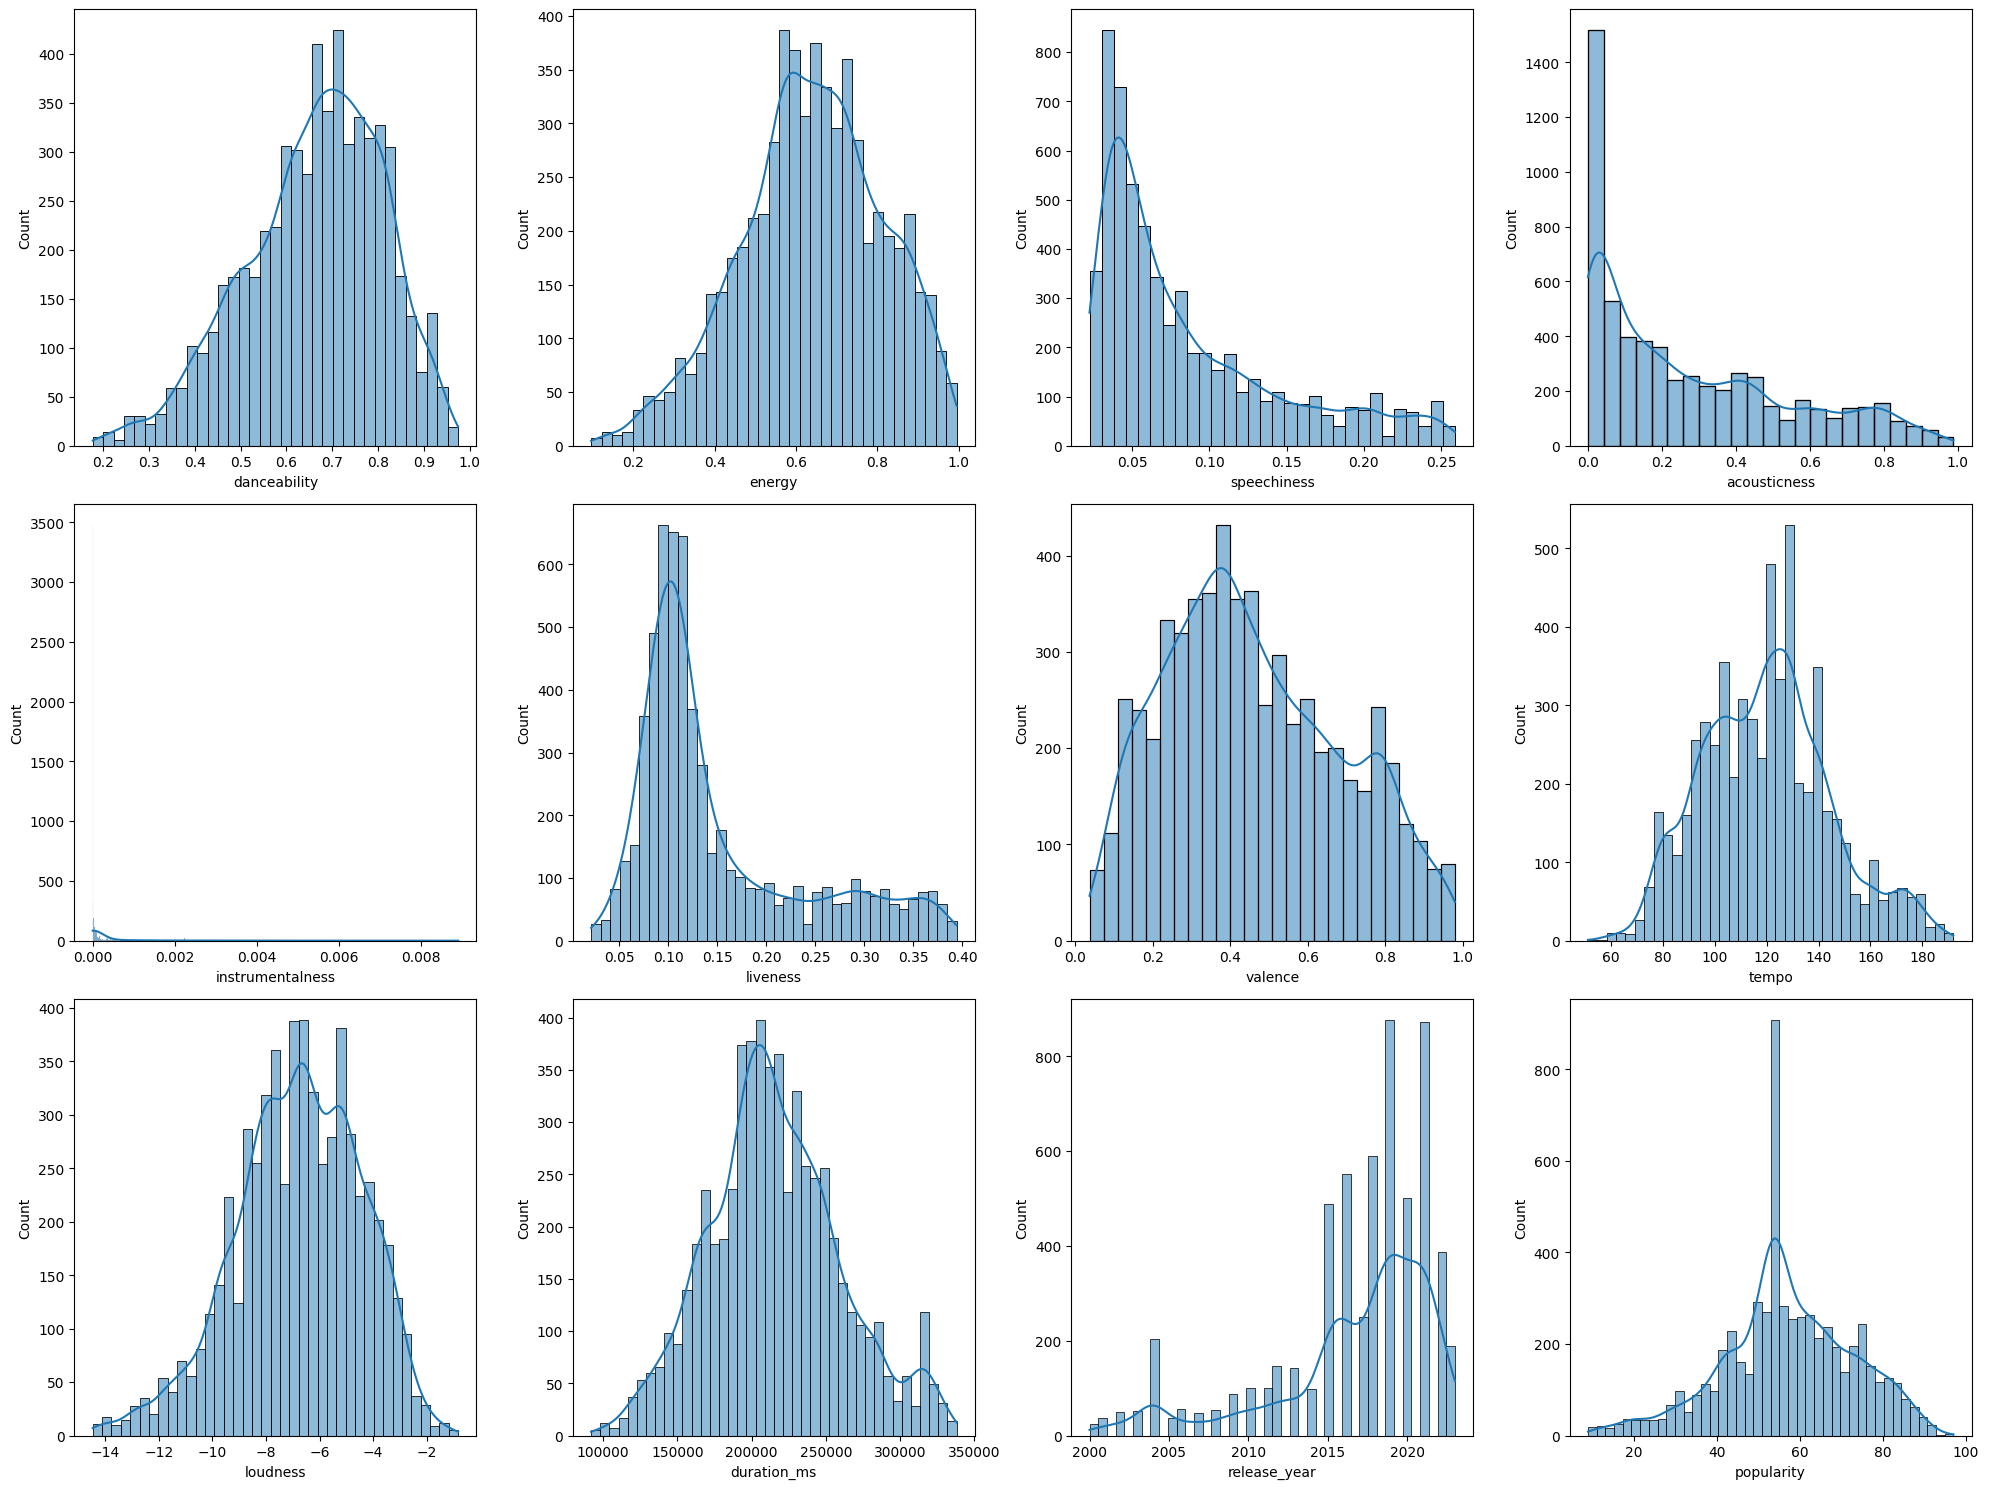

In [ ]:
# Remove outliers based on IQR
df = preprocessing.remove_outliers_iqr(df, spoti.NUMERICAL_FEATURES, quantile=0.25, threshold=1.5)
plotting.plot_feature_distribution(df, spoti.NUMERICAL_FEATURES, cols=4, rows=3)

In [ ]:
plotting.plot_genres(df["genres"])

In [ ]:
plotting.plot_genres(df["normalized_genres"])

# KNN

In [ ]:
spoti.TRACKS_TYPES

['top_track', 'liked_track', 'playlist']

In [ ]:
# Choose a user
user = np.random.choice(users_list.USERS)
user = user.username
user = "dany"
print(f"User: {user}")

User: dany


In [ ]:
df_knn = df.copy()
scaler = StandardScaler()
df_knn[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])

In [ ]:
nn = NearestNeighboursRecommender(
    df_knn,
    features_columns=spoti.NUMERICAL_FEATURES,
    username_column="username",
    affinity_column="affinity",
    n_neighbours=10,
)

df_user_tracks = nn.pick_user_tracks(user)
df_user_tracks

,album,artists,available_markets,disc_number,duration_ms,episode,explicit,external_ids,external_urls,href,...,type_features,uri_features,track_href,analysis_url,duration_ms_features,time_signature,time_range,affinity,release_year,normalized_genres
20066,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.233059,NaN,True,{'isrc': 'USUM72306013'},{'spotify': 'https://open.spotify.com/track/44...,https://api.spotify.com/v1/tracks/444vevlQjTnK...,...,audio_features,spotify:track:444vevlQjTnKioLLncteGv,https://api.spotify.com/v1/tracks/444vevlQjTnK...,https://api.spotify.com/v1/audio-analysis/444v...,205288,4,medium_term,1.00,1.234355,"[rap, rap, pop, rap]"
20116,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.886165,NaN,False,{'isrc': 'FR3IV2100200'},{'spotify': 'https://open.spotify.com/track/6D...,https://api.spotify.com/v1/tracks/6Dt6avd8V0rB...,...,audio_features,spotify:track:6Dt6avd8V0rBotNLj9yMy3,https://api.spotify.com/v1/tracks/6Dt6avd8V0rB...,https://api.spotify.com/v1/audio-analysis/6Dt6...,176027,4,short_term,1.00,1.039153,"[pop, french]"
20067,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.694637,NaN,False,{'isrc': 'USUM72306024'},{'spotify': 'https://open.spotify.com/track/6S...,https://api.spotify.com/v1/tracks/6Sjg6cp8yXtK...,...,audio_features,spotify:track:6Sjg6cp8yXtKX5DrcEl7HV,https://api.spotify.com/v1/tracks/6Sjg6cp8yXtK...,https://api.spotify.com/v1/audio-analysis/6Sjg...,184607,4,medium_term,0.98,1.234355,"[rap, rap, pop, rap]"
20068,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-1.704550,NaN,True,{'isrc': 'USUM72306388'},{'spotify': 'https://open.spotify.com/track/0c...,https://api.spotify.com/v1/tracks/0cuNKdwaFrDJ...,...,audio_features,spotify:track:0cuNKdwaFrDJ4G1hYxI6aI,https://api.spotify.com/v1/tracks/0cuNKdwaFrDJ...,https://api.spotify.com/v1/audio-analysis/0cuN...,139361,4,medium_term,0.96,1.234355,"[rap, rap, pop, rap]"
20069,"{'album_type': 'ALBUM', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AD, AE, AR, AT, AU, BE, BG, BH, BO, BR, CA, C...",1,-0.411619,NaN,True,{'isrc': 'USUM72306012'},{'spotify': 'https://open.spotify.com/track/6V...,https://api.spotify.com/v1/tracks/6V1TqJxtw3P0...,...,audio_features,spotify:track:6V1TqJxtw3P0ouCKICvl9l,https://api.spotify.com/v1/tracks/6V1TqJxtw3P0...,https://api.spotify.com/v1/audio-analysis/6V1T...,197287,5,medium_term,0.94,1.234355,"[rap, rap, pop, rap]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20252,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,0.281618,NaN,False,{'isrc': 'USUM70972068'},{'spotify': 'https://open.spotify.com/track/3D...,https://api.spotify.com/v1/tracks/3DamFFqW32Wi...,...,audio_features,spotify:track:3DamFFqW32WihKkTVlwTYQ,https://api.spotify.com/v1/tracks/3DamFFqW32Wi...,https://api.spotify.com/v1/audio-analysis/3Dam...,228347,4,NaN,NaN,-1.498475,"[indie, pop]"
20257,"{'album_type': 'album', 'artists': [{'external...",[{'external_urls': {'spotify': 'https://open.s...,"[AR, AU, AT, BE, BO, BR, BG, CA, CL, CO, CR, C...",1,-0.567435,NaN,False,{'isrc': 'USQX92000198'},{'spotify': 'https://open.spotify.com/track/2K...,https://api.spotify.com/v1/tracks/2KMLGJ1mPfRE...,...,audio_features,spotify:track:2KMLGJ1mPfRE4GNdL92rl3,https://api.spotify.com/v1/tracks/2KMLGJ1mPfRE...,https://api.spotify.com/v1/audio-analysis/2KML...,190307,4,NaN,NaN,0.648748,[soundtrack]
20260,"{'album_type': 'album', 'artists': [{'external...",[{'ext

In [ ]:
df_recommendations = nn.recommend_from(df_user_tracks, filter_out_if_seen=False)
df_recommendations[spoti.PRETTY_PRINT_FEATURES + ["seen"]]

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity,seen
18987,paul,A$AP Rocky,"Everyday (feat. Rod Stewart, Miguel & Mark Ron...",-0.327262,1.334233,-1.785916,0.132554,1.782804,-0.997868,-0.353973,2.221646,-0.553005,1.220596,-0.807155,1.010143,-0.327262,1.334233,False
18988,paul,A$AP Rocky,"Everyday (feat. Rod Stewart, Miguel & Mark Ron...",-0.327262,1.334233,-1.785916,0.132554,1.782804,-0.997868,-0.353973,2.221646,-0.553005,1.220596,-0.807155,1.010143,-0.327262,1.334233,False
11076,owen,Young Thug,Sin (feat. Jaden Smith),0.258344,0.002325,1.522044,-1.454265,1.326999,-1.014916,-0.353973,1.425823,-0.996626,0.248195,-2.122394,-0.294528,0.258344,0.002325,False
18749,paul,Damso,Autotune,-0.132060,0.446294,0.125350,-0.896579,0.076068,-0.928318,-0.353973,2.325449,-1.271670,0.006636,-1.367720,1.738980,-0.132060,0.446294,False
20036,lsirwguhu,Stromae,ave cesaria,-0.717666,0.002325,0.419391,0.121055,1.951621,-0.594144,-0.351750,0.664600,-0.366685,-0.281864,-0.623712,0.754221,-0.717666,0.002325,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8808,jaslkh,Iliona,Si tu m'aimes demain,1.039153,0.129173,1.288148,-0.787341,-0.935143,1.348289,0.561665,-0.546435,0.023701,-0.608324,-1.170200,-0.886165,1.039153,0.129173,True
15179,brenda,Owl City,Fireflies,-1.498475,1.461082,-0.997352,0.138303,-0.717370,-0.931712,-0.353973,-0.373430,0.054754,2.457209,-0.002142,0.281618,-1.498475,1.461082,True
19170,paul,Daft Punk,One More Time,-3.060092,1.334233,-0.322394,0.339530,0.786786,-0.962263,-0.353973,2.094776,0.072499,0.115578,-0.778998,2.335303,-3.060092,1.334233,True
11852,owen,Daft Punk,One More Time,-3.060092,1.334233,-0.322394,0.339530,0.786786,-0.962263,-0.353973,2.094776,0.072499,0.115578,-0.778998,2.335303,-3.060092,1.334233,True


In [ ]:
nn.plot_recommendation(
    df_recommended_tracks=df_recommendations,
    df_recommended_from=df_user_tracks,
    username=user,
)

In [ ]:
# From a user's perspective, we want to recommend songs that are similar to the songs that the user has listened to.
# We can use the cosine similarity to find the most similar songs to a given song.
df_knn = df.copy()

# df_knn = remove_outliers_iqr(df_knn, NUMERICAL_FEATURES, threshold=0.15)

# normalize numeric features
scaler = StandardScaler()
df_knn[spoti.NUMERICAL_FEATURES] = scaler.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])

# Run PCA on the numeric features
n_components = len(spoti.NUMERICAL_FEATURES)
n_components = 3
pca = PCA(n_components=n_components)
latent_features = pca.fit_transform(df_knn[spoti.NUMERICAL_FEATURES])
df_knn, latent_columns = dimensionality_reduction.add_latent_features(df_knn, latent_features)
df_knn.loc[df_knn["username"] != user, "username"] = ""
if n_components <= 3: plotting.plot_latent_space(df_knn, color=df_knn["username"], text=df_knn["username"], title="PCA").show()
latent_columns = spoti.NUMERICAL_FEATURES

# Get songs that the user has listened to
track_types = ["top_track"]
df_knn_user = df_knn[df_knn["username"] == user]
df_knn_user = df_knn_user[df_knn_user["type"].isin(track_types)]
df_knn_user

# Sample N songs from the songs that the user has listened to, more chance of sampling central songs of the user
PRE_SELECT_N = 20
SELECT_N = 10
df_knn_user_sample = df_knn_user.sample(PRE_SELECT_N)
# sort by affinity with random weights
weights = np.random.rand(len(df_knn_user_sample)) * 2 + 1
df_knn_user_sample["affinity"] = df_knn_user_sample["affinity"] * weights
df_knn_user_sample = df_knn_user_sample.sort_values(by="affinity", ascending=False)
df_knn_user_sample = df_knn_user_sample.drop_duplicates(subset=["id"])
df_knn_user_sample = df_knn_user_sample.head(SELECT_N)
# shuffle the dataframe
display(df_knn_user_sample[spoti.PRETTY_PRINT_FEATURES + latent_columns])

# Get songs that the user has not listened to
df_knn_user_complement = df_knn[(~df_knn["id"].isin(df_knn_user["id"])) & (~df_knn["id"].isin(df_knn_user_sample["id"]))].drop_duplicates(subset=["id"])
df_knn_not_user = df_knn[(df_knn["username"] != user) & (~df_knn["id"].isin(df_knn_user_sample["id"]))].drop_duplicates(subset=["id"])

print(f"User songs selected: {len(df_knn_user)}")
print(f"User songs complement: {len(df_knn_user_complement)}")
print(f"Songs unknown to user: {len(df_knn_not_user)}")

# Get the songs that are most similar to the sampled songs
knn = NearestNeighbors(metric="minkowski", p=2, radius=1)

# From all the songs that the user has not listened to, we only want to consider the songs that are similar to the sampled songs
choosen_df = df_knn_user_complement
knn.fit(choosen_df[latent_columns])
distances, indices = knn.kneighbors(df_knn_user_sample[latent_columns], n_neighbors=1000, return_distance=True)
# Set the distances to the original dataframe
choosen_df = choosen_df.iloc[indices.flatten()].copy()
choosen_df["distance"] = distances.flatten()
choosen_df = choosen_df.sort_values(by="distance")
choosen_df = choosen_df.drop_duplicates(subset=["id"])

TOP_N = 20
choosen_df = choosen_df.head(TOP_N)
# shuffle the dataframe
choosen_df = choosen_df.sample(frac=1)

choosen_df[spoti.PRETTY_PRINT_FEATURES]

,username,artists_names,name,release_year,popularity,danceability,energy,speechiness,acousticness,instrumentalness,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,loudness,duration_ms,release_year,popularity
20172,dany,Greta Van Fleet,Trip the Light Fantastic,0.843951,-0.441645,-2.721500,1.725123,-0.028598,-1.024383,2.031303,...,-0.028598,-1.024383,2.031303,-0.980102,-0.304578,1.181615,1.252092,1.286286,0.843951,-0.441645
20178,dany,Damso,Σ. MOROSE,0.843951,-0.187948,0.399342,-0.287148,-0.612703,0.360100,1.246470,...,-0.612703,0.360100,1.246470,-0.581036,-0.814741,1.229290,-0.430458,1.067951,0.843951,-0.187948
20068,dany,Post Malone,Texas Tea,1.234355,0.382870,-0.990669,-0.333143,-0.291952,-1.027363,-0.345125,...,-0.291952,-1.027363,-0.345125,1.679563,-0.393302,-1.629788,0.294779,-1.704550,1.234355,0.382870
20072,dany,Post Malone,Buyer Beware,1.234355,0.382870,-0.148643,1.046700,-0.307145,-0.915117,-0.353973,...,-0.307145,-0.915117,-0.353973,0.145585,-0.251344,-0.000752,1.068223,-0.942969,1.234355,0.382870
20077,dany,Post Malone,Laugh It Off,1.234355,0.446294,-1.064179,-0.609112,-0.769703,-0.981122,-0.353973,...,-0.769703,-0.981122,-0.353973,-0.706754,-1.080914,1.312762,0.417216,0.686882,1.234355,0.446294
20071,dany,Post Malone,Speedometer,1.234355,0.636567,0.272370,1.098444,-0.462457,-1.002922,1.777386,...,-0.462457,-1.002922,1.777386,2.175511,0.511683,-0.243781,-0.348549,-1.196926,1.234355,0.636567
20135,dany,Nothing But Thieves,Amsterdam,0.063142,0.763415,-1.004034,1.702125,2.626887,-1.020235,-0.327197,...,2.626887,-1.020235,-0.327197,1.056745,0.924250,1.965274,0.951759,1.261332,0.063142,0.763415
20088,dany,Greta Van Fleet,The Falling Sky,1.234355,-0.251372,-2.728183,1.621634,-0.612703,-1.035339,0.373151,...,-0.612703,-1.035339,0.373151,-0.408031,-0.317887,-1.166302,1.511898,0.072412,1.234355,-0.251372
20124,dany,Greta Van Fleet,Frozen Light,1.234355,-0.251372,-3.155879,1.483650,-0.688671,-1.033798,3.054663,...,-0.688671,-1.033798,3.054663,-0.930507,-0.167056,0.825521,2.355306,1.269389,1.234355,-0.251372
20194,dany,Post Malone,Landmine,1.234355,0.446294,-2.594528,-0.459629,-0.909821,-0.906065,-0.099287,...,-0.909821,-0.906065,-0.099287,-0.096622,-1.169638,2.120830,-0.043096,-0.694637,1.234355,0.446294


User songs selected: 69
User songs complement: 2694
Songs unknown to user: 2694


NameError: name 'NearestNeighbors' is not defined